# DSA 210 Project: Gender Bias in Online Toxicity Analysis

This notebook analyzes whether comments containing female-related expressions differ in toxicity levels compared to other comments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

## Data Loading
We load the dataset and inspect its structure.

In [2]:
df = pd.read_csv("/Users/busranurenci/Desktop/DSA210-PROJECT/data/train.csv")

print(df.head())


                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\rWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\rMore\rI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


## Feature Engineering
We create a feature to detect whether a comment contains female-related words.

In [3]:
keywords = ["she", "woman", "women", "female", "girl"]

def is_women_related(text):
    text = str(text).lower()
    for k in keywords:
        if k in text:
            return 1
    return 0

df["women_related"] = df["comment_text"].apply(is_women_related)

## Toxicity Score
We compute a combined toxicity score from multiple labels.

In [4]:
toxicity_columns = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

df["toxicity_score"] = df[toxicity_columns].mean(axis=1)

## Comparing Groups
We compare the average toxicity between women-related comments and others.

In [5]:
women_avg = df[df["women_related"] == 1]["toxicity_score"].mean()
other_avg = df[df["women_related"] == 0]["toxicity_score"].mean()

print("Women-related:", women_avg)
print("Others:", other_avg)

Women-related: 0.027618385208369556
Others: 0.03736096009292965


## Hypothesis Testing (t-test)
We test whether the difference between groups is statistically significant.

In [6]:
women_group = df[df["women_related"] == 1]["toxicity_score"]
other_group = df[df["women_related"] == 0]["toxicity_score"]

t_stat, p_value = ttest_ind(women_group, other_group, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -9.289176284658804
p-value: 1.778660834781799e-20


## Normality Check
We test whether the data follows a normal distribution before applying parametric tests.

In [7]:
from scipy.stats import shapiro

women_sample = women_group.sample(500, random_state=42)
other_sample = other_group.sample(500, random_state=42)

print("Women-related:", shapiro(women_sample))
print("Others:", shapiro(other_sample))

Women-related: ShapiroResult(statistic=np.float64(0.25240495901576143), pvalue=np.float64(1.3777616492719283e-40))
Others: ShapiroResult(statistic=np.float64(0.32903084551117145), pvalue=np.float64(4.295358389278018e-39))


## Mann-Whitney U Test
A non-parametric test used when normality assumption is not satisfied.

In [8]:
from scipy.stats import mannwhitneyu

u_stat, mw_p = mannwhitneyu(women_group, other_group)

print("U statistic:", u_stat)
print("p-value:", mw_p)

U statistic: 834433263.0
p-value: 7.032657641814198e-12


## Visualization: Average Toxicity

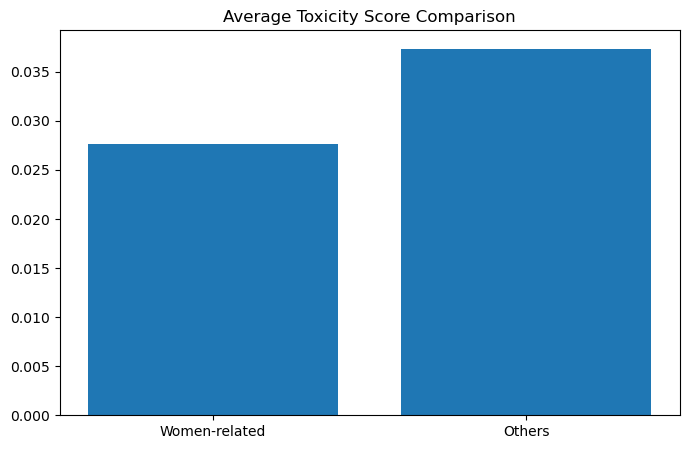

In [9]:
labels = ["Women-related", "Others"]
values = [women_avg, other_avg]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Average Toxicity Score Comparison")
plt.show()

## Visualization: Group Counts

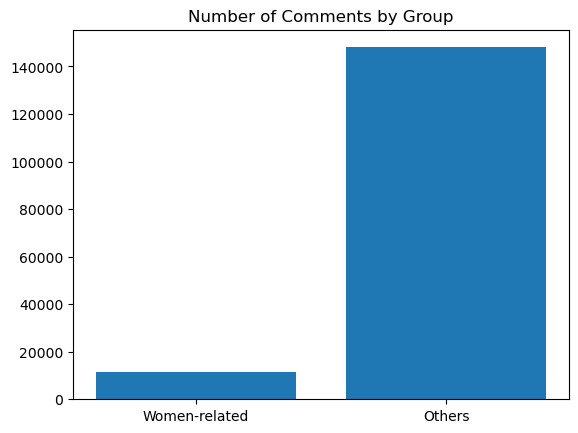

In [10]:
women_count = df["women_related"].sum()
other_count = len(df) - women_count

plt.bar(labels, [women_count, other_count])
plt.title("Number of Comments by Group")
plt.show()

## Visualization: Histogram

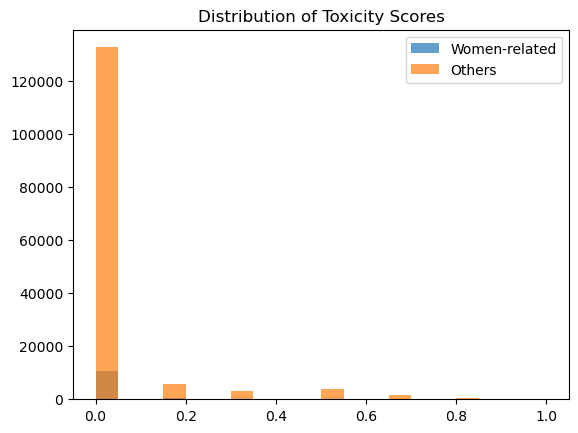

In [11]:
plt.hist(women_group, bins=20, alpha=0.7, label="Women-related")
plt.hist(other_group, bins=20, alpha=0.7, label="Others")
plt.legend()
plt.title("Distribution of Toxicity Scores")
plt.show()

## Visualization: Boxplot

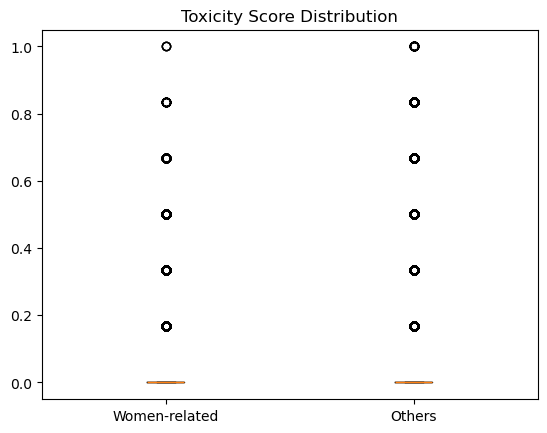

In [12]:
plt.boxplot([women_group, other_group], tick_labels=["Women-related", "Others"])
plt.title("Toxicity Score Distribution")
plt.show()

## Conclusion

The results suggest that there is a statistically significant difference between women-related comments and other comments.

Both parametric and non-parametric tests support this conclusion.

## Machine Learning

For the May 5 milestone, machine learning models are applied to predict whether a comment is toxic or not.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## Feature and Target Selection

The target variable is `toxic`. The features used are `women_related` and `toxicity_score`.

In [14]:
X = df[["women_related", "toxicity_score"]]
y = df["toxic"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1: Logistic Regression

In [15]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9941093529688234
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     28859
           1       0.94      1.00      0.97      3056

    accuracy                           0.99     31915
   macro avg       0.97      1.00      0.98     31915
weighted avg       0.99      0.99      0.99     31915



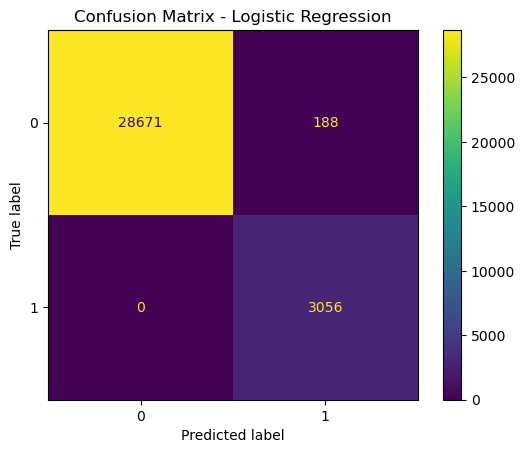

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Model 2: Decision Tree Classifier

In [17]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.9941093529688234
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     28859
           1       0.94      1.00      0.97      3056

    accuracy                           0.99     31915
   macro avg       0.97      1.00      0.98     31915
weighted avg       0.99      0.99      0.99     31915



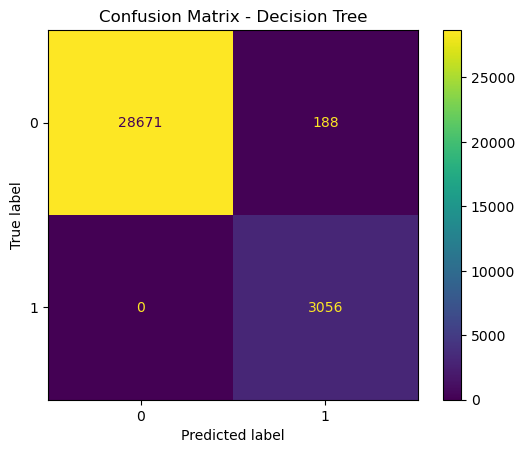

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Machine Learning Interpretation

Both Logistic Regression and Decision Tree models were used to predict whether a comment is toxic. The results are evaluated using accuracy, classification report, and confusion matrices.